In [21]:
# Add cle_fun to PYTHON_PATH
import sys
sys.path.append("../../../../../clonscal_bak")

from analytic.formulas import *

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

import os
import json
import pandas as pd


In [29]:
home = os.environ.get("HOME")
# Set the folder containing the JSON files
folder_path = f"{home}/gitrepos/clonscal_bak/results/sim_data/unmod/autocorr"


# List all JSON files in the folder
json_files = [f for f in os.listdir(folder_path) if f.endswith(".json")]

# Initialize a list to store data
data_list = []

# Loop through the JSON files and load them into a DataFrame
for file in json_files:

    file_path = os.path.join(folder_path, file)

    with open(file_path, "r") as f:
        data = json.load(f)
    
    # Flatten the structure
    flattened_data = {
        "mean_dS_max": data["params"]["mean_dS_max"],
        "trajs": data["params"]["trajs"],
        "dt": data["params"]["dt"],
        "sigma_abs": data["params"]["sigma_abs"],
        "sigma_phase": data["params"]["sigma_phase"],
        "lambda_abs": data["params"]["lambda_abs"],
        "history_grid_size": data["params"]["history_grid_size"],
        "key": file.split(".json")[0],
    }
    # mean, variance_real, variance_imag, covariance_reim, counter
    # Add moment values
    for moment in ["1_moment", "2_moment"]:
        for key in data[moment]:
            flattened_data[f"{moment}_{key}"] = data[moment][key]

    data_list.append(flattened_data)

# Create the DataFrame
df = pd.DataFrame(data_list).sort_values("dt")

# rounding
df.keys()

Index(['mean_dS_max', 'trajs', 'dt', 'sigma_abs', 'sigma_phase', 'lambda_abs',
       'history_grid_size', 'key', '1_moment_mean_real', '1_moment_mean_imag',
       '1_moment_variance_real', '1_moment_variance_imag',
       '1_moment_covariance_reim', '1_moment_counter', '1_moment_thermal_time',
       '1_moment_auto_corr', '2_moment_mean_real', '2_moment_mean_imag',
       '2_moment_variance_real', '2_moment_variance_imag',
       '2_moment_covariance_reim', '2_moment_counter', '2_moment_thermal_time',
       '2_moment_auto_corr'],
      dtype='object')

In [30]:
npy_files = [f for f in os.listdir(folder_path) if f.endswith(".npy")]

from collections import defaultdict
histograms = defaultdict(dict)

for file in npy_files:
    hist_name = file.split(".")[0]
    key = "_".join(hist_name.split("_")[:3])
    obs_name = hist_name.split(key+"_")[-1]
    file_path = os.path.join(folder_path, file)
    dat = np.load(file_path)
    histograms[key][obs_name] = dat

# load .npz files (histograms)
npy_files = [f for f in os.listdir(folder_path) if f.endswith(".npz")]
histories = defaultdict(dict)

for file in npy_files:
    hist_name = file.split(".")[0]
    key = "_".join(hist_name.split("_")[:3])
    obs_name = hist_name.split(key+"_")[-1]
    file_path = os.path.join(folder_path, file)
    dat = np.load(file_path)
    histories[key][obs_name] = dat

In [31]:

from scipy.optimize import curve_fit

def fit_exp(x, tau):
    return np.exp(-x / tau)

def my_acf(data, lmax=None):
    dat = data[:lmax]
    normed_data = dat - np.mean(dat)
    acf = np.correlate(normed_data, normed_data, mode="full")
    acf = acf[acf.size // 2 :]
    acf /= acf[0]
    return acf

def my_acl(data, lmax=None):
    acf = my_acf(data, lmax=lmax)
    acf = acf[:lmax]
    lag = np.array(range(len(acf)))
    p, _ = curve_fit(fit_exp, lag, acf)
    return p[0]

In [32]:
from tqdm import tqdm
autocorr_lengths_real = {}
autocorr_lengths_imag = {}
for lamb, lamb_group in df.groupby("lambda_abs"):
    for (sigma_abs, sigma_phase), sigma_group in lamb_group.groupby(["sigma_abs", "sigma_phase"]):
        sigma = sigma_abs*np.exp(1j*sigma_phase)

        for dt, dr_group in sigma_group.groupby("dt"):
            key = dr_group["key"].unique()
            if len(key) != 1: print("Non unique")
            key = key[0]
            histor = histories[key]

            acls_real = {}
            acls_imag = {}
            for name, hist in histories[key].items():
                # real part
                acl_vals = []
                for (lt, dat) in tqdm(zip(hist["meas_times"].T, hist["result"].T)):
                    lt = lt[~np.isnan(lt)]
                    dat = dat[~np.isnan(dat)].real
                    acl_vals.append(np.array(my_acl(dat, lmax = int(15/dt))))
                acls_real[f"{name}_real"] = np.array(acl_vals)

                # imag part
                acl_vals = []
                for (lt, dat) in tqdm(zip(hist["meas_times"].T, hist["result"].T)):
                    lt = lt[~np.isnan(lt)]
                    dat = dat[~np.isnan(dat)].imag
                    acl_vals.append(np.array(my_acl(dat, lmax = int(10/dt))))
                acls_imag[f"{name}_imag"] = np.array(acl_vals)

            autocorr_lengths_real[key] = acls_real
            autocorr_lengths_imag[key] = acls_imag

500it [00:03, 164.28it/s]
500it [00:03, 162.76it/s]
500it [00:02, 178.08it/s]
500it [00:02, 175.24it/s]
500it [00:00, 1458.72it/s]
500it [00:00, 1433.34it/s]
500it [00:00, 1272.28it/s]
500it [00:00, 1229.87it/s]


In [33]:
df.keys()

Index(['mean_dS_max', 'trajs', 'dt', 'sigma_abs', 'sigma_phase', 'lambda_abs',
       'history_grid_size', 'key', '1_moment_mean_real', '1_moment_mean_imag',
       '1_moment_variance_real', '1_moment_variance_imag',
       '1_moment_covariance_reim', '1_moment_counter', '1_moment_thermal_time',
       '1_moment_auto_corr', '2_moment_mean_real', '2_moment_mean_imag',
       '2_moment_variance_real', '2_moment_variance_imag',
       '2_moment_covariance_reim', '2_moment_counter', '2_moment_thermal_time',
       '2_moment_auto_corr'],
      dtype='object')

0.001
0.005
0.001
0.005


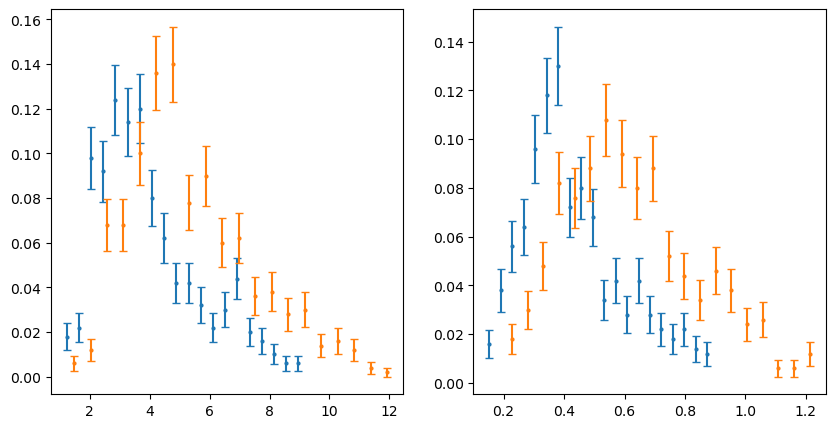

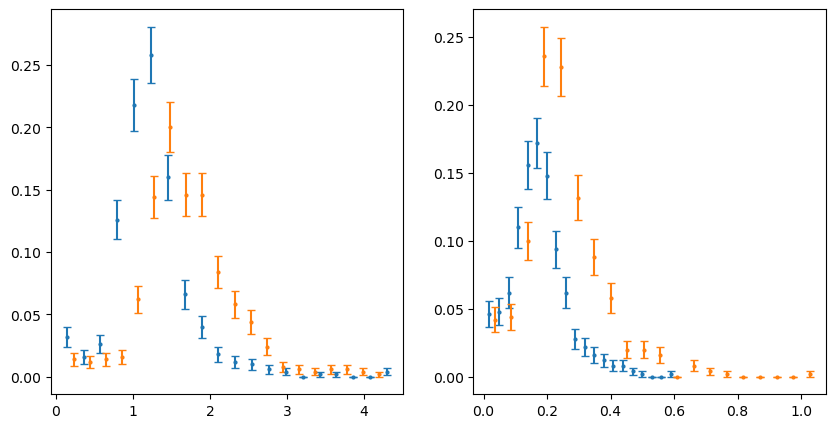

In [ ]:
from tqdm import tqdm
for lamb, lamb_group in df.groupby("lambda_abs"):
    for (sigma_abs, sigma_phase), sigma_group in lamb_group.groupby(["sigma_abs", "sigma_phase"]):
        sigma = sigma_abs*np.exp(1j*sigma_phase)

        for obs_name in ["1_moment", "2_moment"]:
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            for dt, dr_group in sigma_group.groupby("dt"):
                key = dr_group["key"].unique()
                if len(key) != 1: print("Non unique")
                key = key[0]
                hist_grid_size = dr_group["history_grid_size"].values[0]
                print(hist_grid_size)

                acl_real = autocorr_lengths_real[key]
                acl_imag = autocorr_lengths_imag[key]
                # for (_, acl_real),(_, acl_imag)  in zip(autocorr_lengths_real[key].items(), autocorr_lengths_imag[key].items()):
                hist_counts, x_edges = np.histogram(acl_real[f"{obs_name}_real"], bins=20)
                hist_errors = np.sqrt(hist_counts)
                total_counts = np.sum(hist_counts)
                hist = hist_counts / total_counts
                hist_errors = hist_errors / total_counts 
                X_centers = (x_edges[:-1] + x_edges[1:]) / 2
                axes[0].errorbar(X_centers*dt*10, hist, yerr=hist_errors, fmt='o', markersize=2, capsize=3, label=f"$\lambda = {lamb}$")

                hist_counts, x_edges = np.histogram(acl_imag[f"{obs_name}_imag"], bins=20)
                hist_errors = np.sqrt(hist_counts)
                total_counts = np.sum(hist_counts)
                hist = hist_counts / total_counts
                hist_errors = hist_errors / total_counts 
                X_centers = (x_edges[:-1] + x_edges[1:]) / 2
                axes[1].errorbar(X_centers*dt, hist, yerr=hist_errors, fmt='o', markersize=2, capsize=3, label=f"$\lambda = {lamb}$")


[[0.00055 0.00055 0.00055 ... 0.00055 0.00055 0.00055]
 [0.00155 0.00155 0.00155 ... 0.00155 0.00155 0.00155]
 [0.0025  0.0025  0.0025  ... 0.0025  0.0025  0.0025 ]
 ...
 [    nan     nan     nan ...     nan     nan     nan]
 [    nan     nan     nan ...     nan     nan     nan]
 [    nan     nan     nan ...     nan     nan     nan]]


(1.0, 2.0)

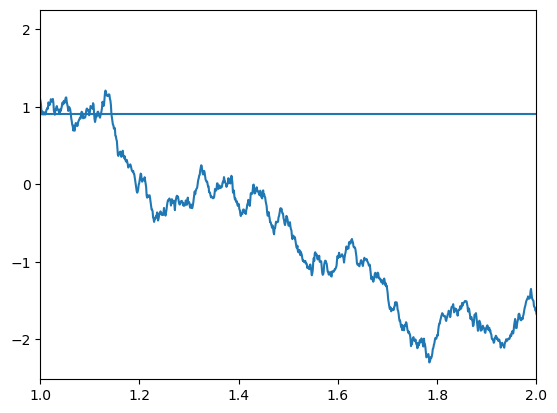

In [272]:
key = "20250324_000014_MfXvT0"
obs = "1_moment"
dat = histories[key][obs]["result"]
lt = histories[key][obs]["meas_times"]
# dat_mean = np.nanmean(dat, axis = 1)
# lt_mean = np.nanmean(lt, axis = 1)

print(lt)
plt.hlines(n_moment_rho(2, -1+1j, 1), 0, 10)
plt.plot(lt[:, 0], dat[:, 0])
plt.xlim(1, 2)

In [49]:
# imports
# Add cle_fun to PYTHON_PATH
import sys, os, json
sys.path.append("../../../../../clonscal_bak")


from analytic.formulas import *

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "double"
os.environ["MY_NUMBA_TARGET"] = "numba"

from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from simulation.gpu_handler import GPU_handler

from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)

import src.scal as scal
from src.numba_target import (
    use_cuda,
    my_act_parallel_loop
)
from src.utils import (
    update_histogram_complex, 
    update_histogram_real,
    calculate_stats_complex,
    gaussian_modified_density_drift_kernel
)

if use_cuda: from numba import cuda

parameters = {
        "trajs": int(5e2),
        "mean_dS_max": 50,
        "max_langevin_time": 10,
        "lambda_abs": 1,
    }

# sigma = -1+1j
# parameters["sigma_abs"] = np.abs(sigma)
# parameters["sigma_phase"] = np.angle(sigma)


import tqdm
def run_sim(dt, maximal_lt, auto_corr=None, thermal_time=None):
    config = Config(trajs=int(1e2), dt = dt, ada_step = True, sigma = -1+1j, interaction = 1)
    sim = ComplexLangevinSimulation(config)
    if auto_corr == None: auto_corr = dt
    if thermal_time == None: thermal_time = 0
    sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  
                            langevin_history_full=True, langevin_history=True, thermal_time=thermal_time, 
                            auto_corr=auto_corr, maximal_lt=maximal_lt, history_grid_size=2*auto_corr)
    
    sim.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  
                        langevin_history_full=True, langevin_history=True, thermal_time=thermal_time, 
                        auto_corr=auto_corr, maximal_lt=maximal_lt, history_grid_size=2*auto_corr)

    if use_cuda:
        gpu_handler = GPU_handler(sim)
        gpu_handler.to_device()

    max_lt_global = np.max([obj.maximal_lt for obj in sim.trackers.values()])
    with tqdm.tqdm(total=max_lt_global) as pbar:
        while np.min(sim.langevin_time[sim.alive]) < max_lt_global:
            lt = np.min(sim.langevin_time[sim.alive])
            pbar.update(lt- pbar.n)
            sim.step()
            sim.kill_trajs()

            for _, tr in sim.trackers.items():
                tr.mark_equilibrated_trajs()
                tr.compute()
        sim.finish()
    return sim  

# dt = 1e-3
# autocorr_corr = dt
# autocorr_uncorr = dt*5e2

# sim = run_sim(dt, 0.5, auto_corr=autocorr_corr, thermal_time = 0)
# data_corr = sim.trackers["1_moment"].history_result_full[:, 0]
# lt_corr = sim.trackers["1_moment"].history_meas_times_full[:, 0]
# data_corr = data_corr[~np.isnan(data_corr)]
# lt_corr = lt_corr[~np.isnan(lt_corr)]

# sim = run_sim(dt, 50, auto_corr=autocorr_uncorr, thermal_time = 0)
# data_uncorr = sim.trackers["1_moment"].history_result_full[:, 0]
# lt_uncorr = sim.trackers["1_moment"].history_meas_times_full[:, 0]
# data_uncorr = data_uncorr[~np.isnan(data_uncorr)]
# lt_uncorr = lt_uncorr[~np.isnan(lt_uncorr)]


In [50]:
import numba
@numba.njit(parallel=True)
def autocorrelate(x, tmax=10000):
    # correlate
    if tmax is None or tmax > len(x):
        tmax = len(x)

    # subtract mean
    y = x - np.mean(x)
    
    acf = np.zeros(tmax, dtype=x.dtype)
    for dt_ in numba.prange(tmax):
        corr = 0.0
        for t in range(len(x)-dt_):
            corr += y[t]*y[t+dt_]
        corr /= len(x)-dt_
        acf[dt_] = corr

    # normalize
    acf /= acf[0]
    
    return acf


In [52]:

import tqdm
from scipy.optimize import curve_fit
max_lt = 50

for dt in [1e-2, 5e-3, 1e-3, 5e-4]:
        sim = run_sim(dt, max_lt, auto_corr=dt, thermal_time = 0)

        # avg over acls
        acfs = []

        # only take alive trajs, dead trajs have a different shape
        full_traj_data = sim.trackers["1_moment"].history_result_full[:, sim.alive]
        full_traj_lt = sim.trackers["1_moment"].history_meas_times_full[:, sim.alive]

        # print(full_traj_lt.shape)
        # print(full_traj_data.shape)
        # loop over alive trajs
        for traj_idx in tqdm.tqdm(range(sim.alive.sum())): 
                data = full_traj_data[:, traj_idx]
                data = data[~np.isnan(data)]
                
                acfs.append(autocorrelate(data, tmax = int(max_lt/dt)))

        acfs_arr = np.array(acfs)

        acf_mean = np.mean(acfs_arr, axis = 0)
        acf_std = np.std(acfs_arr, axis = 0)

        lag = np.array(range(len(acf_mean)))
        
        p, _ = curve_fit(fit_exp, lag, acf_mean, sigma=1/acf_std)

        print(dt, p*sim.trackers["1_moment"].history_grid_size)

100%|█████████▉| 49.995284862520904/50 [00:01<00:00, 46.25it/s]
100%|██████████| 99/99 [00:00<00:00, 1785.71it/s]


0.01 [0.96096763]


100%|█████████▉| 49.99658591135455/50 [00:02<00:00, 23.53it/s] 
100%|██████████| 100/100 [00:00<00:00, 480.16it/s]


0.005 [0.91509716]


100%|█████████▉| 49.99990366985145/50 [00:10<00:00,  4.72it/s]  
100%|██████████| 100/100 [00:05<00:00, 19.75it/s]


0.001 [0.89971335]


100%|█████████▉| 49.99976025396208/50 [00:21<00:00,  2.37it/s]  
100%|██████████| 100/100 [00:20<00:00,  4.90it/s]

0.0005 [1.04805257]


In [45]:
sim.trackers["1_moment"].init_history_size

100000

In [ ]:
sim.

/opt/miniconda3/envs/cle/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/miniconda3/envs/cle/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


array([1.04805257])

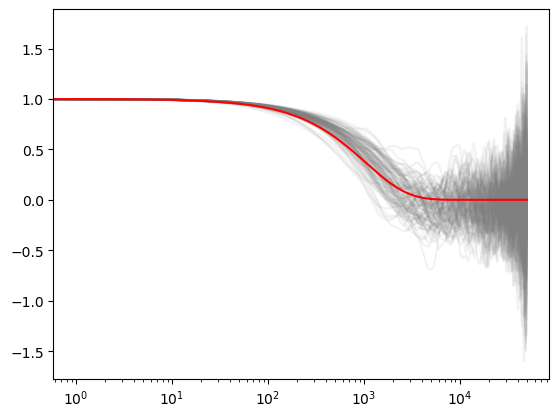

In [53]:
acfs_arr = np.array(acfs)

from scipy.optimize import curve_fit

acf_mean = np.mean(acfs_arr, axis = 0)
acf_std = np.std(acfs_arr, axis = 0)
lag = np.array(range(len(acf_mean)))

p, _ = curve_fit(fit_exp, lag, acf_mean, sigma=1/acf_std)

for acf in acfs_arr:
    plt.plot(acf, color = "gray", alpha = 0.1)

plt.plot(lag, fit_exp(lag, p), color = "red")
plt.xscale("log")
p*dt*2

/opt/miniconda3/envs/cle/lib/python3.10/site-packages/numpy/lib/function_base.py:628: ComplexWarning: Casting complex values to real discards the imaginary part
  a = asarray(a, dtype=dtype, order=order)
/opt/miniconda3/envs/cle/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/miniconda3/envs/cle/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


array([0.20314439])

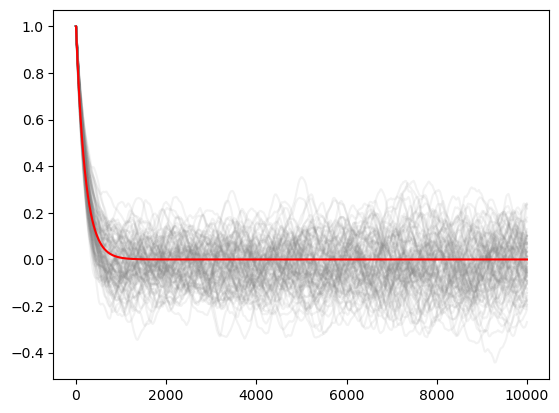

In [102]:
acfs_arr = np.array(acfs)

from scipy.optimize import curve_fit

acf_mean = np.mean(acfs_arr, axis = 0)
acf_std = np.std(acfs_arr, axis = 0)
lag = np.array(range(len(acf_mean)))

p, _ = curve_fit(fit_exp, lag, acf_mean, sigma=1/acf_std)

for acf in acfs_arr:
    plt.plot(acf, color = "gray", alpha = 0.1)

plt.plot(lag, fit_exp(lag, p), color = "red")
p*dt

/opt/miniconda3/envs/cle/lib/python3.10/site-packages/numpy/lib/function_base.py:628: ComplexWarning: Casting complex values to real discards the imaginary part
  a = asarray(a, dtype=dtype, order=order)
/opt/miniconda3/envs/cle/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/miniconda3/envs/cle/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


array([0.31447151])

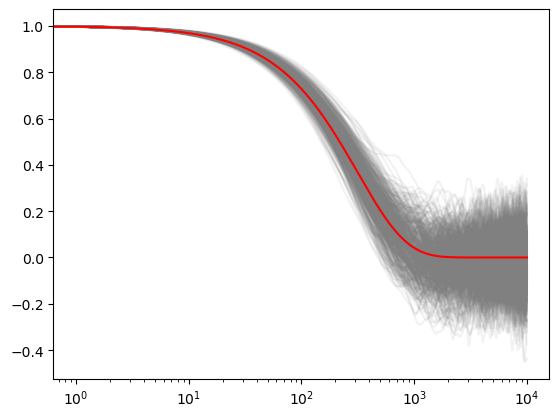

In [23]:
acfs_arr = np.array(acfs)

from scipy.optimize import curve_fit

lag = np.array(range(len(acfs_arr[0])))
std = np.std(acfs_arr, axis = 0)
acf_mean = np.mean(acfs_arr, axis = 0)
p, _ = curve_fit(fit_exp, lag, acf_mean, sigma=1/std)
# p, _ = curve_fit(fit_exp, lag, acf)

for acf in acfs_arr:
    plt.plot(acf, color = "gray", alpha = 0.1)

plt.semilogx(lag, fit_exp(lag, p), color = "red")
p*dt

In [ ]:

# acl over traj avg
data = sim.trackers["1_moment"].history_result_full
data = np.nanmean(data, axis = 1)
data = data[~np.isnan(data)]

lt = sim.trackers["1_moment"].history_meas_times_full
lt = np.nanmean(lt, axis = 1)
lt = lt[~np.isnan(lt)][:30000]

/opt/miniconda3/envs/cle/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/miniconda3/envs/cle/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


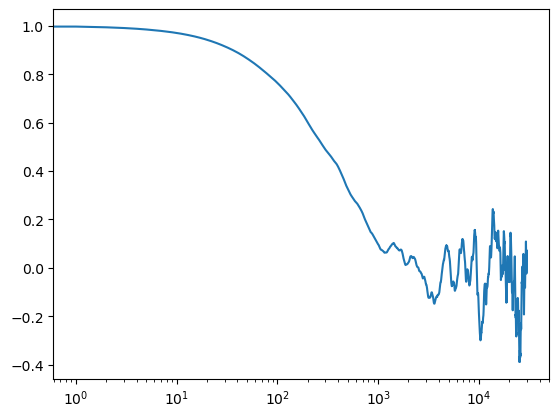

In [132]:
plt.semilogx(autocorrelate(data, 30000))

In [ ]:
for traj_idx in tqdm.tqdm(range(sim.trajs)): 
    data_corr = sim.trackers["1_moment"].history_result_full[:, traj_idx]
    data_corr = data_corr[~np.isnan(data_corr)]
    # remove nans

    lt_corr = sim.trackers["1_moment"].history_meas_times_full[:, traj_idx]
    lt_corr = lt_corr[~np.isnan(lt_corr)]
    # remove nans

    


100%|██████████| 1000/1000 [00:00<00:00, 2512.38it/s]


In [82]:
import tqdm
dt = 5e-4
autocorr_corr = dt
max_lts = np.array(range(1, 3, 1))
means = []
for max_lt in [2]:
    sim = run_sim(dt, max_lt, auto_corr=autocorr_corr, thermal_time = 0)
    
    for traj_idx in tqdm.tqdm(range(sim.trajs)): 
        data_corr = sim.trackers["1_moment"].history_result_full[:, traj_idx]
        lt_corr = sim.trackers["1_moment"].history_meas_times_full[:, traj_idx]
        data_corr = data_corr[~np.isnan(data_corr)]
        lt_corr = lt_corr[~np.isnan(lt_corr)]

        # acf = autocorrelate(data_corr)
        # acl = my_acl(data_corr)
        
        # lts.append(lt_corr)
        # acls.append(acl)
        # acfs.append(acf)

# mean_acl1 = np.mean(acls)
# mean_lt1 = np.mean(lts)
    
# lts2 = np.array(lts)
# acfs2 = np.array(acfs)

  0%|          | 0/2 [00:00<?, ?it/s]

100%|█████████▉| 1.9999999999998352/2 [00:01<00:00,  1.69it/s] 
100%|██████████| 1000/1000 [00:00<00:00, 17107.74it/s]


In [8]:

from scipy.optimize import curve_fit

def fit_exp(x, tau):
    return np.exp(-x / tau)

def my_acf(data):
    normed_data = data - np.mean(data)
    acf = np.correlate(normed_data, normed_data, mode="full")
    acf = acf[acf.size // 2 :]
    acf /= acf[0]
    return acf

def my_acl(data, lmax=None):
    acf = my_acf(data, lmax=lmax)
    acf = acf[:lmax]
    lag = np.array(range(len(acf)))
    p, _ = curve_fit(fit_exp, lag, acf)
    return p[0]

In [ ]:
import tqdm
dt = 5e-4
autocorr_corr = dt
max_lts = np.array(range(1, 3, 1))
means = []
for max_lt in [2]:
    sim = run_sim(dt, max_lt, auto_corr=autocorr_corr, thermal_time = 0)
    acls = []
    acfs = []
    lts = []
    
    for traj_idx in tqdm.tqdm(range(sim.trajs)): 
        data_corr = sim.trackers["1_moment"].history_result_full[:, traj_idx]
        lt_corr = sim.trackers["1_moment"].history_meas_times_full[:, traj_idx]
        data_corr = data_corr[~np.isnan(data_corr)]
        lt_corr = lt_corr[~np.isnan(lt_corr)]

        acf = my_acf(data_corr)
        acl = my_acl(data_corr)
        
        lts.append(lt_corr)
        acls.append(acl)
        acfs.append(acf)

mean_acl1 = np.mean(acls)
mean_lt1 = np.mean(lts)
    
lts2 = np.array(lts)
acfs2 = np.array(acfs)

 93%|█████████▎| 1.8584999999998508/2 [00:00<00:00,  2.36it/s] /Users/fabianhelmberger/gitrepos/clonscal_bak/results/money_plots/notebooks/unmod/../../../../../clonscal_bak/simulation/observables.py:96: RuntimeWarning: invalid value encountered in divide
  tr.history_result  = np.where(mask, tr.history_result / tr.history_counter, np.nan)
/Users/fabianhelmberger/gitrepos/clonscal_bak/results/money_plots/notebooks/unmod/../../../../../clonscal_bak/simulation/observables.py:97: RuntimeWarning: invalid value encountered in divide
  tr.history_meas_times = np.where(mask, tr.history_meas_times / tr.history_counter, np.nan)
/Users/fabianhelmberger/gitrepos/clonscal_bak/results/money_plots/notebooks/unmod/../../../../../clonscal_bak/simulation/observables.py:103: RuntimeWarning: invalid value encountered in divide
  tr.history_result_full  = np.where(mask, tr.history_result_full / tr.history_counter_full, np.nan)
/Users/fabianhelmberger/gitrepos/clonscal_bak/results/money_plots/notebooks/unmo

In [ ]:
mean_acl2 = np.mean(acfs2, axis = 0)
mean_lt2 = np.mean(lts2, axis = 0)

(2495,)

In [ ]:
plt.plot(lts2.T, acfs2.T, color = "gray", alpha = 0.05)
plt.plot(lt_mean2, acf_mean2, color = "red", label = "traj. mean")
acf = my_acf(acf_mean2)
acl = my_acl(acf_mean2)

plt.plot(lt_mean2, fit_exp(lt_mean2, acl*dt), color = "blue", label = "exp fit over traj mean")
plt.plot(lt_mean1, fit_exp(lt_mean1, acl*dt), color = "blue", label = "exp fit over traj mean")

plt.legend()
print(acl)

AttributeError: 'list' object has no attribute 'T'

Text(0, 0.5, 'Auto corr length')

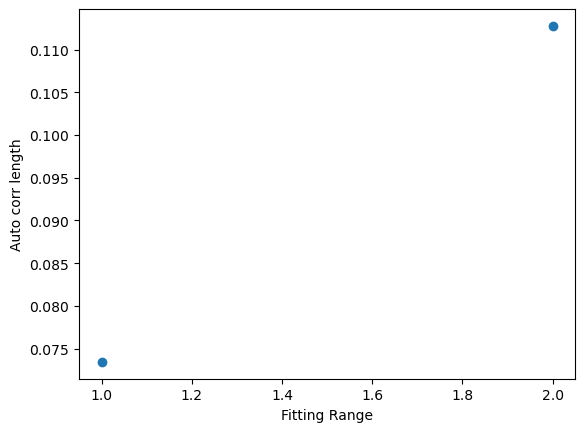

In [ ]:
import tqdm
dt = 5e-4
autocorr_corr = dt
max_lts = np.array(range(1, 3, 1))
means = []
for max_lt in [1]:
    sim = run_sim(dt, max_lt, auto_corr=autocorr_corr, thermal_time = 0)
    acls = []
    acfs = []
    lts = []

    for traj_idx in tqdm.tqdm(range(sim.trajs)): 
        data_corr = sim.trackers["1_moment"].history_result_full[:, traj_idx]
        lt_corr = sim.trackers["1_moment"].history_meas_times_full[:, traj_idx]
        data_corr = data_corr[~np.isnan(data_corr)]
        lt_corr = lt_corr[~np.isnan(lt_corr)]

        acf = my_acf(data_corr)
        acl = my_acl(data_corr)
        lts.append(lt_corr)
        acls.append(acl)
        acfs.append(acf)
        mean_acl = np.mean(acls)
        std_acl = np.std(acls)
    
    means.append(mean_acl*sim.history_grid_size)
lts = np.array(lts)
acfs = np.array(acfs)

0.7186361261532647


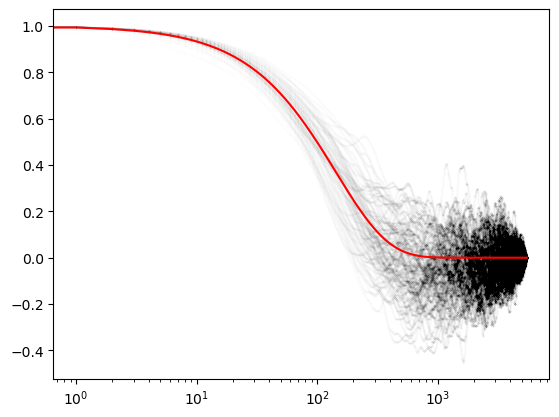

In [192]:
for acl, acf in zip(acls, acfs):
    lag = np.array(range(len(acf)))
    plt.semilogx(lag, acf, marker="x", markersize=1, color = "black", alpha = 0.005)

plt.semilogx(lag, fit_exp(lag, np.mean(acls)), color = "red")
print(np.mean(acls)*dt)

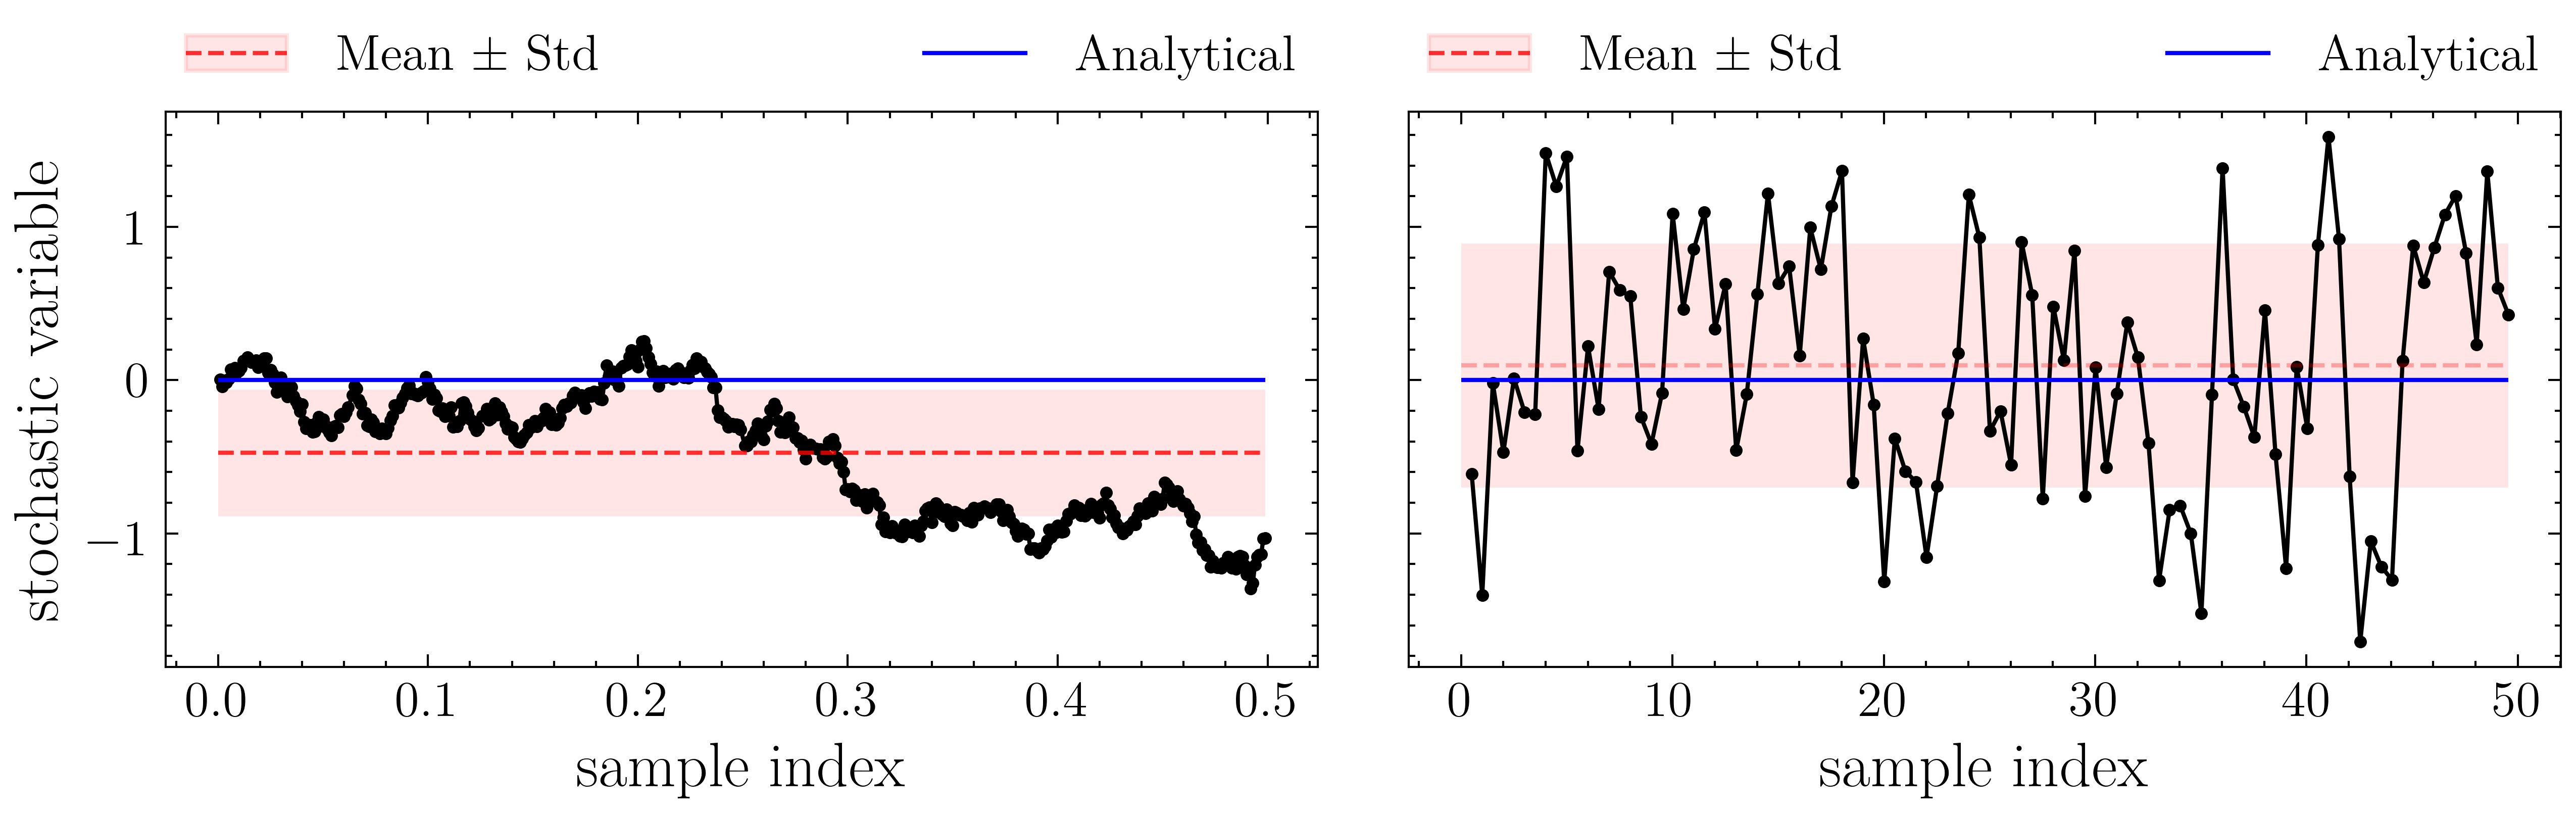

In [110]:


import scienceplots
plt.style.use(['science', "ieee"])
plt.rcParams['text.latex.preamble']=r'\usepackage{lmodern}'

plt.rcParams.update({
    'font.size': 20,  # Main font size
    'axes.labelsize': 15,  # Axis labels
    'axes.titlesize': 18,  # Title size
    'legend.fontsize': 12,  # Legend font
    'xtick.labelsize': 12,  # Tick labels
    'ytick.labelsize': 12,
    'font.family' : 'lmodern'
})

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

fig, ax = plt.subplots(1,2,figsize=(9, 3.2), sharey="row")
ax = ax.flatten()
mean_corr = np.nanmean(data_corr.real)
std_corr = np.nanstd(data_corr.real)
ax[0].plot(lt_corr, data_corr.real, marker="o", markersize=2, label="Data")
ax[0].hlines(0, 0, lt_corr.max(), color="blue", ls="-", label="Zero Line")

mean_line = ax[0].hlines(mean_corr, 0, lt_corr.max(), color="red", ls="--", alpha=0.8)
fill_region = ax[0].fill_between([0, lt_corr.max()], y1=mean_corr - std_corr, y2=mean_corr + std_corr, 
                                 alpha=0.1, color="red", edgecolor="none")

mean_line_legend = mlines.Line2D([], [], color="red", linestyle="--", alpha=0.8, label="Mean ± Std")
fill_patch_legend = mpatches.Patch(color="red", alpha=0.1)
ana_line_legend = mlines.Line2D([], [], color="blue", ls="-", label="Mean ± Std")

ax[0].legend(handles=[(mean_line_legend, fill_patch_legend), ana_line_legend], labels=["Mean ± Std", "Analytical"], bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left", mode="expand", borderaxespad=0, ncol=3, handletextpad=1)
ax[1].legend(handles=[(mean_line_legend, fill_patch_legend), ana_line_legend], labels=["Mean ± Std", "Analytical"], bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left", mode="expand", borderaxespad=0, ncol=3, handletextpad=1)

fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9, hspace=0.0, wspace=0.0)

ax[0].set_xlabel("sample index")
ax[0].set_ylabel("stochastic variable")

mean_uncorr = np.nanmean(data_uncorr.real)
std_uncorr = np.nanstd(data_uncorr.real)
ax[1].plot(lt_uncorr, data_uncorr.real, marker = "o", markersize = 2)
ax[1].hlines(mean_uncorr, 0, lt_uncorr.max(), color = "red", ls = "--", alpha = 0.3)
ax[1].hlines(0, 0, lt_uncorr.max(), color = "blue", ls = "-")
ax[1].fill_between([0, lt_uncorr.max()], y1 = mean_uncorr-std_uncorr, y2 = mean_uncorr+std_uncorr, alpha = 0.1, color = "red", edgecolor="none")
ax[1].set_xlabel("sample index")

fig.tight_layout()
# fig.savefig("money_plots/autcorr/corr_vs_uncorr.png")

In [30]:
import sys, os, json
sys.path.append("../../clonscal")


from analytic.formulas import *

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "double"
os.environ["MY_NUMBA_TARGET"] = "numba"

from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from simulation.gpu_handler import GPU_handler

from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)

import src.scal as scal
from src.numba_target import (
    use_cuda,
    my_act_parallel_loop
)
from src.utils import (
    update_histogram_complex, 
    update_histogram_real,
    calculate_stats_complex,
    gaussian_modified_density_drift_kernel
)

if use_cuda: from numba import cuda


import tqdm
def run_sim(dt, maximal_lt, auto_corr=None, thermal_time=None):
    steps = 2*maximal_lt/dt
    config = Config(trajs=int(1e3), steps = int(steps), dt = dt, history_grid_size=dt, ada_step = False)
    sim = ComplexLangevinSimulation(config)
    if auto_corr == None: auto_corr = dt
    if thermal_time == None: thermal_time = 0
    sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=True, thermal_time=thermal_time, auto_corr=auto_corr, maximal_lt=maximal_lt)
    sim.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  langevin_history=True, thermal_time=thermal_time, auto_corr=auto_corr, maximal_lt=maximal_lt)

    if use_cuda:
        gpu_handler = GPU_handler(sim)
        gpu_handler.to_device()

    max_lt_global = np.max([obj.maximal_lt for obj in sim.trackers.values()])
    with tqdm.tqdm(total=max_lt_global) as pbar:
        while np.min(sim.langevin_time[sim.alive]) < max_lt_global:
            lt = np.min(sim.langevin_time[sim.alive])
            pbar.update(lt- pbar.n)
            sim.step()
            sim.kill_trajs()

            for _, tr in sim.trackers.items():
                tr.mark_equilibrated_trajs()
                tr.compute()
        sim.finish()
    return sim  

from scipy.optimize import curve_fit

def fit_exp(x, tau):
    return np.exp(-x / tau)

def my_acf(data):
    normed_data = data - np.mean(data)
    acf = np.correlate(normed_data, normed_data, mode="full")
    acf = acf[acf.size // 2 :]
    acf /= acf[0]
    return acf

def my_acl(data, lmax=None):
    acf = my_acf(data)
    acf = acf[:lmax]
    lag = np.array(range(len(acf)))
    p, _ = curve_fit(fit_exp, lag, acf)
    return p[0]

In [20]:
dt_list = np.logspace(-1, -2, 3)
bins = 20

acls = []
acls_cupy = []
for dt in dt_list:
    this_acl = []
    sim = run_sim(dt, 1, auto_corr=dt/2, thermal_time = 0)

    # for traj_idx in tqdm.tqdm(range(sim.trajs)):
    #     count = sim.trackers["1_moment"].history_counter_[:,traj_idx]
    #     mask = count > 0
    #     lt = sim.trackers["1_moment"].history_meas_times_[:,traj_idx][mask]/count[mask]
    #     dat = sim.trackers["1_moment"].history_result_[:,traj_idx][mask]/count[mask]
    #     # this_acl_cupy.append(dt*np.array(my_acf_cupy(dat, lmax = int(1/dt))))
    #     this_acl.append(dt*np.array(my_acl(dat, lmax = int(1/dt))))
    # acls.append(this_acl)


 10%|█         | 0.1/1 [00:00<00:01,  1.81s/it]/home/fahelmberger/gitrepos/clonscal/results/../../clonscal/simulation/observables.py:94: RuntimeWarning: invalid value encountered in true_divide
  tr.history_result  = np.where(mask, tr.history_result / tr.history_counter, np.nan)
/home/fahelmberger/gitrepos/clonscal/results/../../clonscal/simulation/observables.py:95: RuntimeWarning: invalid value encountered in true_divide
  tr.history_meas_times = np.where(mask, tr.history_meas_times / tr.history_counter, np.nan)
100%|█████████▉| 0.9999999999999999/1 [00:00<00:00,  5.27it/s]
 98%|█████████▊| 0.9803060746521972/1 [00:00<00:00,  3.50it/s] 
 99%|█████████▉| 0.9900000000000007/1 [00:00<00:00, 87.72it/s]


In [21]:
sim.trackers["1_moment"].history_counter_

AttributeError: 'ComplexLangevinSimulation' object has no attribute 'history_counter_'

In [83]:
dt_list = np.logspace(-2, -4,3)
bins = 20

acls1 = []
acls2 = []
for dt in dt_list:
    this_acl1 = []
    this_acl2 = []
    sim = run_sim(dt, 1, auto_corr=dt/2, thermal_time = 0)

    for traj_idx in tqdm.tqdm(range(sim.trajs)):
        count = sim.trackers["1_moment"].history_counter_[:,traj_idx]
        mask = count > 0
        lt = sim.trackers["1_moment"].history_meas_times_[:,traj_idx][mask]/count[mask]
        dat = sim.trackers["1_moment"].history_result_[:,traj_idx][mask]/count[mask]
        this_acl1.append(dt*np.array(my_acl(dat, lmax = int(1/dt))))

        count = sim.trackers["2_moment"].history_counter_[:,traj_idx]
        mask = count > 0
        lt = sim.trackers["2_moment"].history_meas_times_[:,traj_idx][mask]/count[mask]
        dat = sim.trackers["2_moment"].history_result_[:,traj_idx][mask]/count[mask]
        this_acl2.append(dt*np.array(my_acl(dat, lmax = int(1/dt))))
        
    acls1.append(this_acl1)
    acls2.append(this_acl2)


 99%|█████████▉| 0.9900000000000007/1 [00:02<00:00,  2.13s/it] 
  0%|          | 0/1000 [00:00<?, ?it/s]/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/numpy/lib/function_base.py:486: ComplexWarning: Casting complex values to real discards the imaginary part
  a = asarray(a, dtype=dtype, order=order)
100%|██████████| 1000/1000 [00:00<00:00, 1016.98it/s]
100%|█████████▉| 0.9990000000000008/1 [00:18<00:00, 18.90s/it]  
100%|██████████| 1000/1000 [00:02<00:00, 349.19it/s]
100%|█████████▉| 0.9999999999999062/1 [03:06<00:00, 186.40s/it]   
100%|██████████| 1000/1000 [01:45<00:00,  9.50it/s]


In [38]:
import sys
import os
sys.path.append("../../clonscal")


from analytic.formulas import *

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "double"
os.environ["MY_NUMBA_TARGET"] = "numba"

from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from simulation.gpu_handler import GPU_handler

from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)

import src.scal as scal
from src.numba_target import (
    use_cuda,
    my_act_parallel_loop
)
from src.utils import (
    update_histogram_complex, 
    update_histogram_real,
    calculate_stats_complex,
    gaussian_modified_density_drift_kernel
)

if use_cuda: from numba import cuda


import tqdm
import cupy as cp
def run_sim(dt, sigma, lamb, pullback, mass_modification, trajs, auto_corr, thermal_time, maximal_lt, history_grid_size):
    config = Config(dt = dt, trajs=int(trajs), sigma = sigma, interaction = lamb, mean_dS_max = 10, history_grid_size=history_grid_size, ada_min = 1e-2, 
                    drift_kernel = gaussian_modified_density_drift_kernel, pullback=pullback, mass_mod=mass_modification )
    sim = ComplexLangevinSimulation(config)
    sim.register_observable('1_moment', obs_kernel=dse_n_moment_kernel, const_param={"order" : 1},  langevin_history_full=True, thermal_time=thermal_time, auto_corr=auto_corr, maximal_lt=maximal_lt)
    sim.register_observable('2_moment', obs_kernel=dse_n_moment_kernel, const_param={"order" : 3},  langevin_history_full=True, thermal_time=thermal_time, auto_corr=auto_corr, maximal_lt=maximal_lt)

    if use_cuda:
        gpu_handler = GPU_handler(sim)
        gpu_handler.to_device()

    def min_lt(sim):
        mask = sim.alive
        return float(cp.min(cp.asarray(sim.langevin_time)[cp.asarray(mask)]))

    max_lt_global = np.max([obj.maximal_lt for obj in sim.trackers.values()])
    with tqdm.tqdm(total=max_lt_global) as pbar:
        while min_lt(sim) < max_lt_global:
            lt = min_lt(sim)
            pbar.update(lt- pbar.n)
            sim.step()
            sim.kill_trajs()

            for _, tr in sim.trackers.items():
                tr.mark_equilibrated_trajs()
                tr.compute()
                
        sim.finish()
    return sim  

from scipy.optimize import curve_fit

def fit_exp(x, tau):
    return np.exp(-x / tau)

def my_acf(data):
    normed_data = data - np.mean(data)
    acf = np.correlate(normed_data, normed_data, mode="full")
    acf = acf[acf.size // 2 :]
    acf /= acf[0]
    return acf

def my_acl(data, lmax=None):
    acf = my_acf(data)
    acf = acf[:lmax]
    lag = np.array(range(len(acf)))
    p, _ = curve_fit(fit_exp, lag, acf)
    return p[0]

In [39]:
sim = run_sim(dt, trajs=int(1e4), auto_corr=dt/10, thermal_time=0, maximal_lt=10, sigma=-1+1j, lamb=2, history_grid_size=1e-2, pullback=10, mass_modification=1)

  1%|          | 0.07100000000000005/10 [00:08<20:39, 124.80s/it] 


KeyboardInterrupt: 

In [35]:
dt_list = np.logspace(-2, -3,2)
bins = 20
max_fitting_range = 10
sigma = -1+1j

acls1_real = []
acls2_real = []
acls1_imag = []
acls2_imag = []

for dt in dt_list:
    this_acl1_real = []
    this_acl2_real = []
    this_acl1_imag = []
    this_acl2_imag = []
    sim = run_sim(dt, trajs=int(1e4), auto_corr=dt/10, thermal_time=0, maximal_lt=10, sigma=sigma, lamb=1, history_grid_size=1e-2, pullback=10, mass_modification=1)

    for traj_idx in tqdm.tqdm(range(sim.trajs)):
        count = sim.trackers["1_moment"].history_counter_full[:,traj_idx]
        mask = count > 0
        lt = sim.trackers["1_moment"].history_meas_times_full[:,traj_idx][mask]/count[mask]
        dat = sim.trackers["1_moment"].history_result_full[:,traj_idx][mask].real/count[mask]
        this_acl1_real.append(np.array(my_acl(dat, lmax = int(max_fitting_range/dt))))

        dat = sim.trackers["1_moment"].history_result_full[:,traj_idx][mask].imag/count[mask]
        this_acl1_imag.append(np.array(my_acl(dat, lmax = int(max_fitting_range/dt))))
        
        count = sim.trackers["2_moment"].history_counter_full[:,traj_idx]
        mask = count > 0
        lt = sim.trackers["2_moment"].history_meas_times_full[:,traj_idx][mask]/count[mask]
        dat = sim.trackers["2_moment"].history_result_full[:,traj_idx][mask].real/count[mask]
        this_acl2_real.append(np.array(my_acl(dat, lmax = int(max_fitting_range/dt))))

        dat = sim.trackers["2_moment"].history_result_full[:,traj_idx][mask].imag/count[mask]
        this_acl2_imag.append(np.array(my_acl(dat, lmax = int(max_fitting_range/dt))))
        
    acls1_real.append(this_acl1_real)
    acls1_imag.append(this_acl1_imag)
    acls2_real.append(this_acl2_real)
    acls2_imag.append(this_acl2_imag)

 99%|█████████▉| 9.891633278534956/10 [00:10<00:00,  1.84it/s]  /home/fahelmberger/gitrepos/clonscal/results/../../clonscal/simulation/observables.py:101: RuntimeWarning: invalid value encountered in true_divide
  tr.history_result_full  = np.where(mask, tr.history_result_full / tr.history_counter_full, np.nan)
/home/fahelmberger/gitrepos/clonscal/results/../../clonscal/simulation/observables.py:102: RuntimeWarning: invalid value encountered in true_divide
  tr.history_meas_times_full = np.where(mask, tr.history_meas_times_full / tr.history_counter_full, np.nan)
100%|█████████▉| 9.99915231484168/10 [00:10<00:00,  1.10s/it] 
100%|██████████| 10000/10000 [00:16<00:00, 600.80it/s]
100%|█████████▉| 9.999896066666865/10 [01:11<00:00,  7.10s/it]   
100%|██████████| 10000/10000 [00:16<00:00, 597.33it/s]


Text(12.398804775062281, 0.5, 'occurrence (arb. units)')

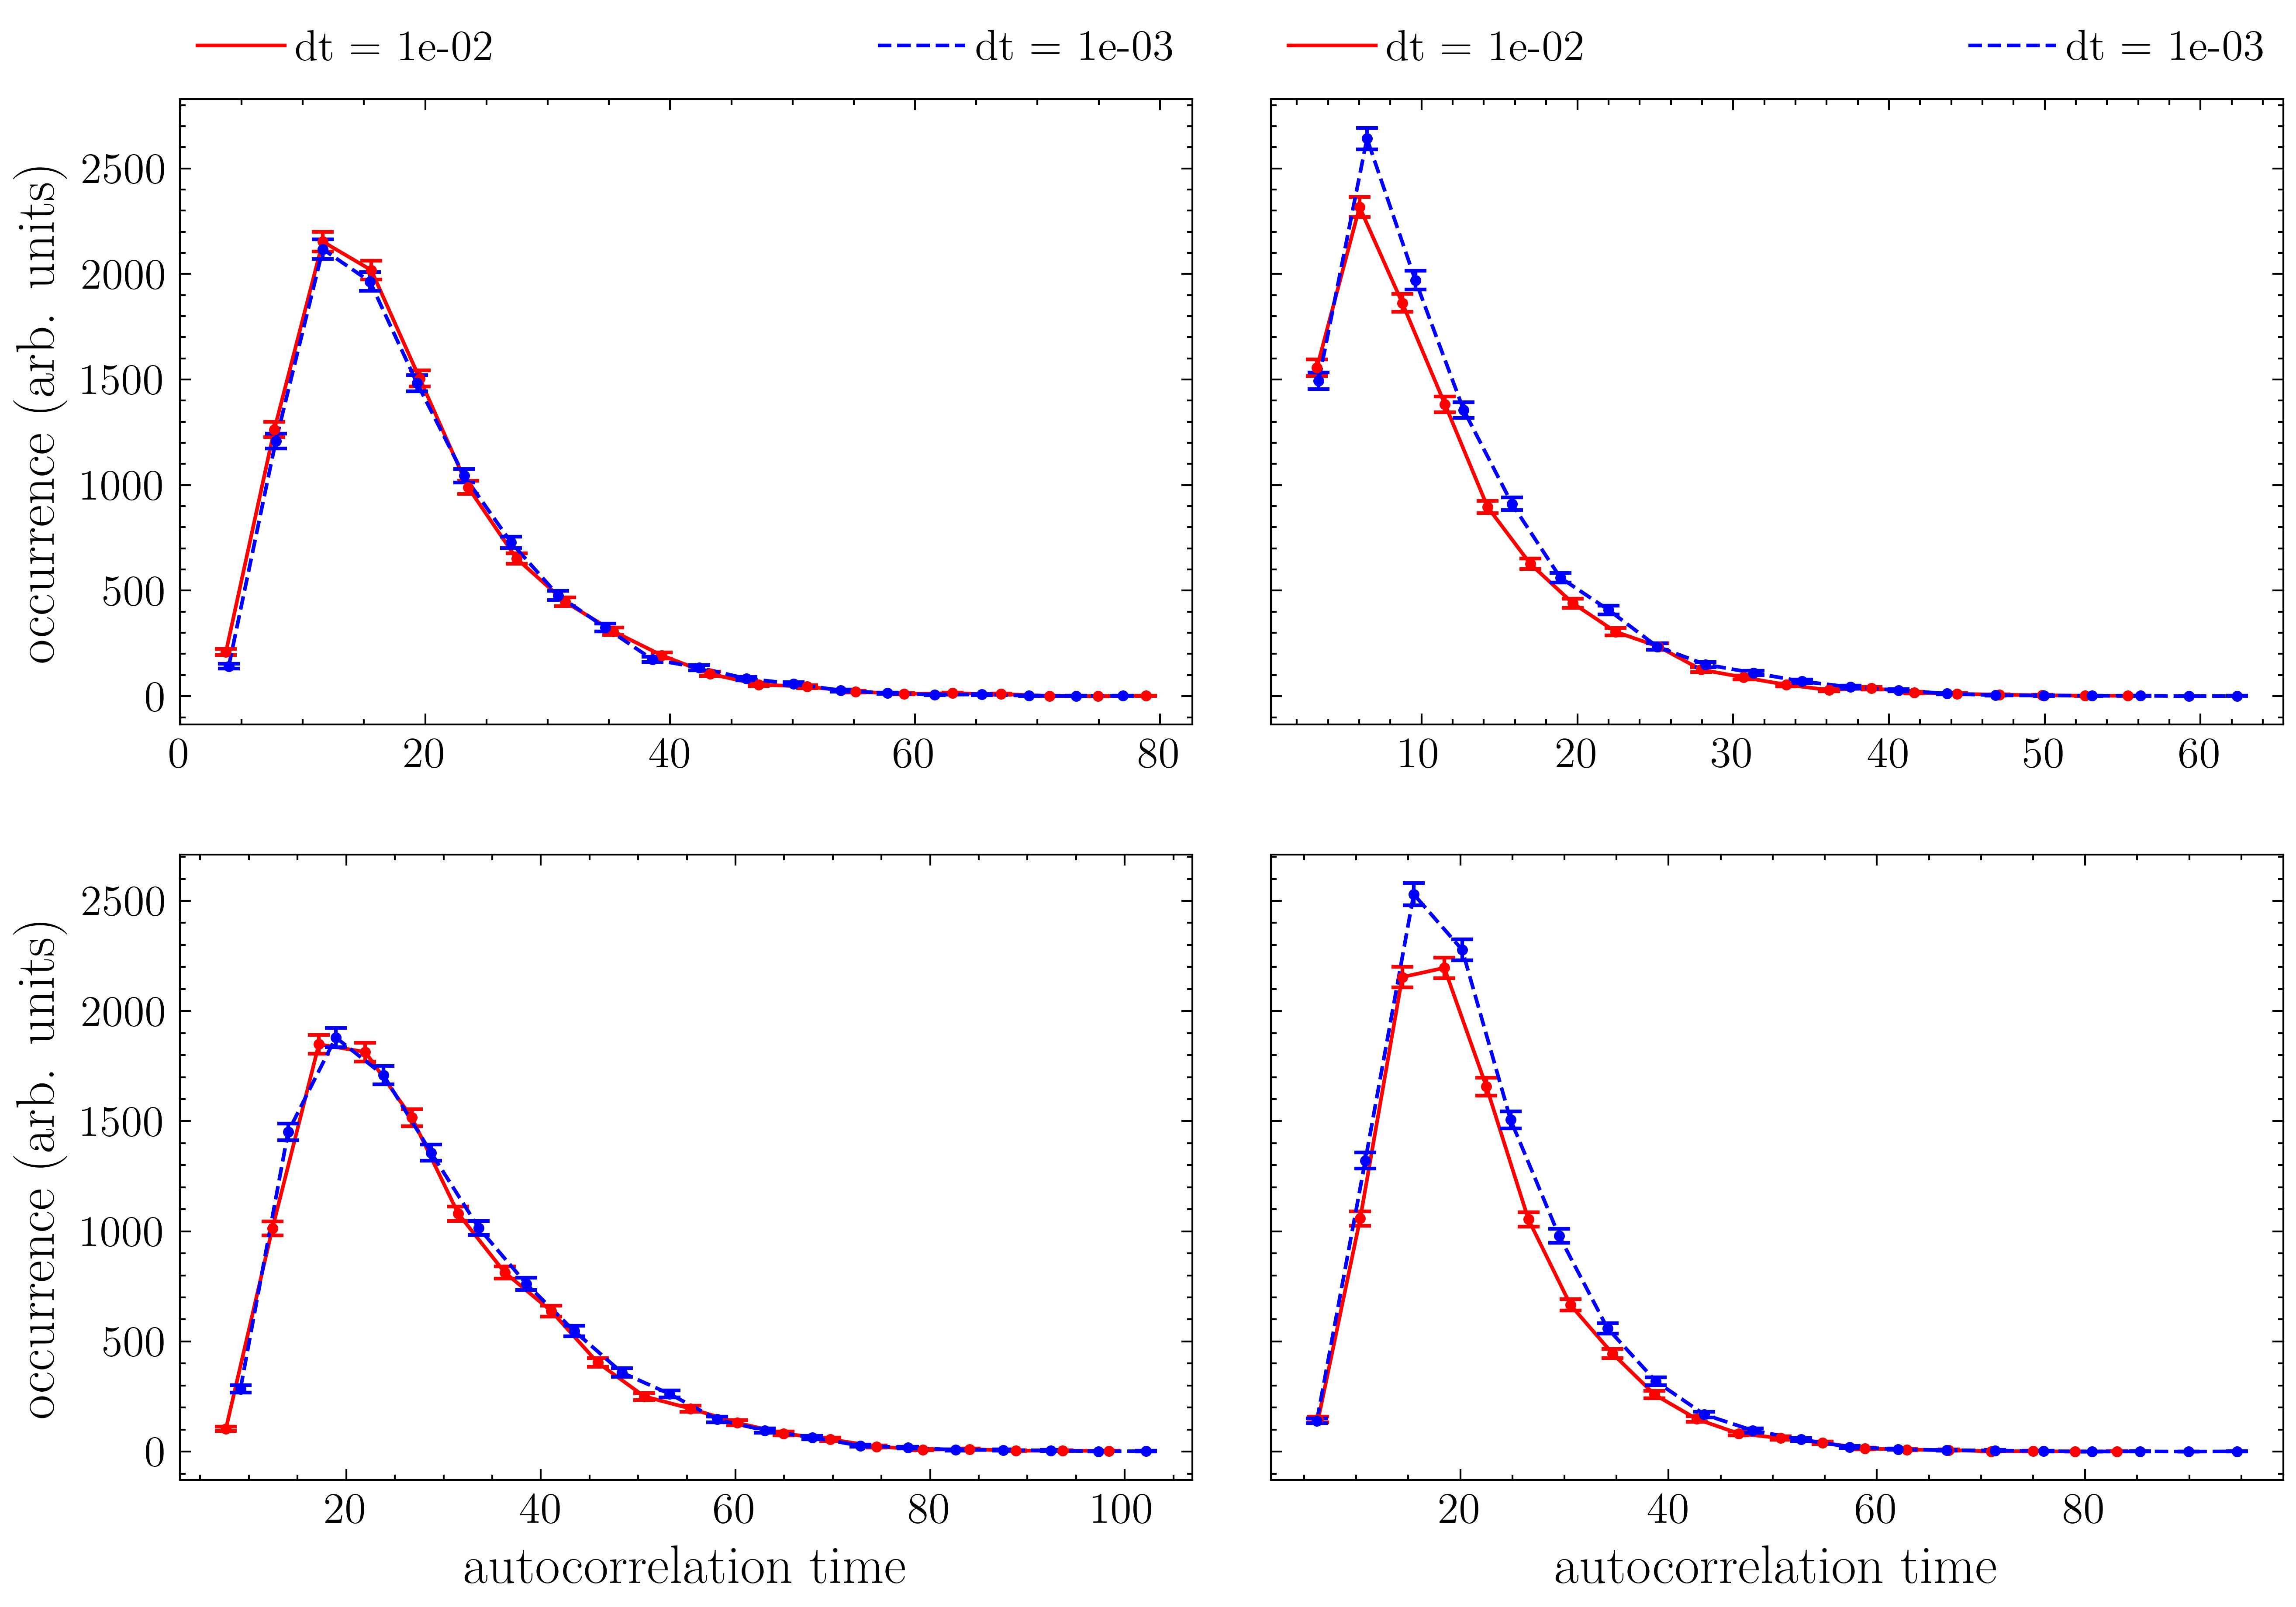

In [36]:
import numpy as np
import matplotlib.pyplot as plt

import scienceplots
plt.style.use(['science', "ieee"])
plt.rcParams['text.latex.preamble']=r'\usepackage{lmodern}'

plt.rcParams.update({
    'font.size': 20,  # Main font size
    'axes.labelsize': 15,  # Axis labels
    'axes.titlesize': 18,  # Title size
    'legend.fontsize': 12,  # Legend font
    'xtick.labelsize': 12,  # Tick labels
    'ytick.labelsize': 12,
    'font.family' : 'lmodern'
})

fig, ax = plt.subplots(2, 2, figsize=(9, 6.4), sharey="row")
ax = ax.flatten()

colors = ["red", "blue", "green"]
for idx, (acl, dt) in enumerate(zip(acls1_real, dt_list)):
    counts, bin_edges = np.histogram(acl, bins=20)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax[0].errorbar(bin_centers, counts, yerr=np.sqrt(counts), fmt='o', color = colors[idx],markersize=2, capsize=3)
    ax[0].plot(bin_centers, counts, color = colors[idx], label = f"dt = {dt:.0e}")
    
for idx, (acl, dt) in enumerate(zip(acls2_real, dt_list)):
    counts, bin_edges = np.histogram(acl, bins=20)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax[1].errorbar(bin_centers, counts, yerr=np.sqrt(counts), fmt='o', color = colors[idx],markersize=2, capsize=3)
    ax[1].plot(bin_centers, counts, color = colors[idx], label = f"dt = {dt:.0e}")

for idx, (acl, dt) in enumerate(zip(acls1_imag, dt_list)):
    counts, bin_edges = np.histogram(acl, bins=20)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax[2].errorbar(bin_centers, counts, yerr=np.sqrt(counts), fmt='o', color = colors[idx],markersize=2, capsize=3)
    ax[2].plot(bin_centers, counts, color = colors[idx], label = f"dt = {dt:.0e}")
    
for idx, (acl, dt) in enumerate(zip(acls2_imag, dt_list)):
    counts, bin_edges = np.histogram(acl, bins=20)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax[3].errorbar(bin_centers, counts, yerr=np.sqrt(counts), fmt='o', color = colors[idx],markersize=2, capsize=3)
    ax[3].plot(bin_centers, counts, color = colors[idx], label = f"dt = {dt:.0e}")

ax[0].legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left", mode="expand", borderaxespad=0, ncol=3, handletextpad=0.25)
ax[1].legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left", mode="expand", borderaxespad=0, ncol=3, handletextpad=0.25)
fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9, hspace=0.0, wspace=0.0)
fig.tight_layout()
ax[2].set_xlabel("autocorrelation time")
ax[3].set_xlabel("autocorrelation time")
ax[0].set_ylabel("occurrence (arb. units)")
ax[2].set_ylabel("occurrence (arb. units)")

In [8]:
config

Available objects for config:
    AliasManager
    DisplayFormatter
    HistoryManager
    IPCompleter
    IPKernelApp
    InlineBackend
    LoggingMagics
    MagicsManager
    OSMagics
    PrefilterManager
    ScriptMagics
    StoreMagics
    ZMQInteractiveShell


NameError: name 'acls' is not defined

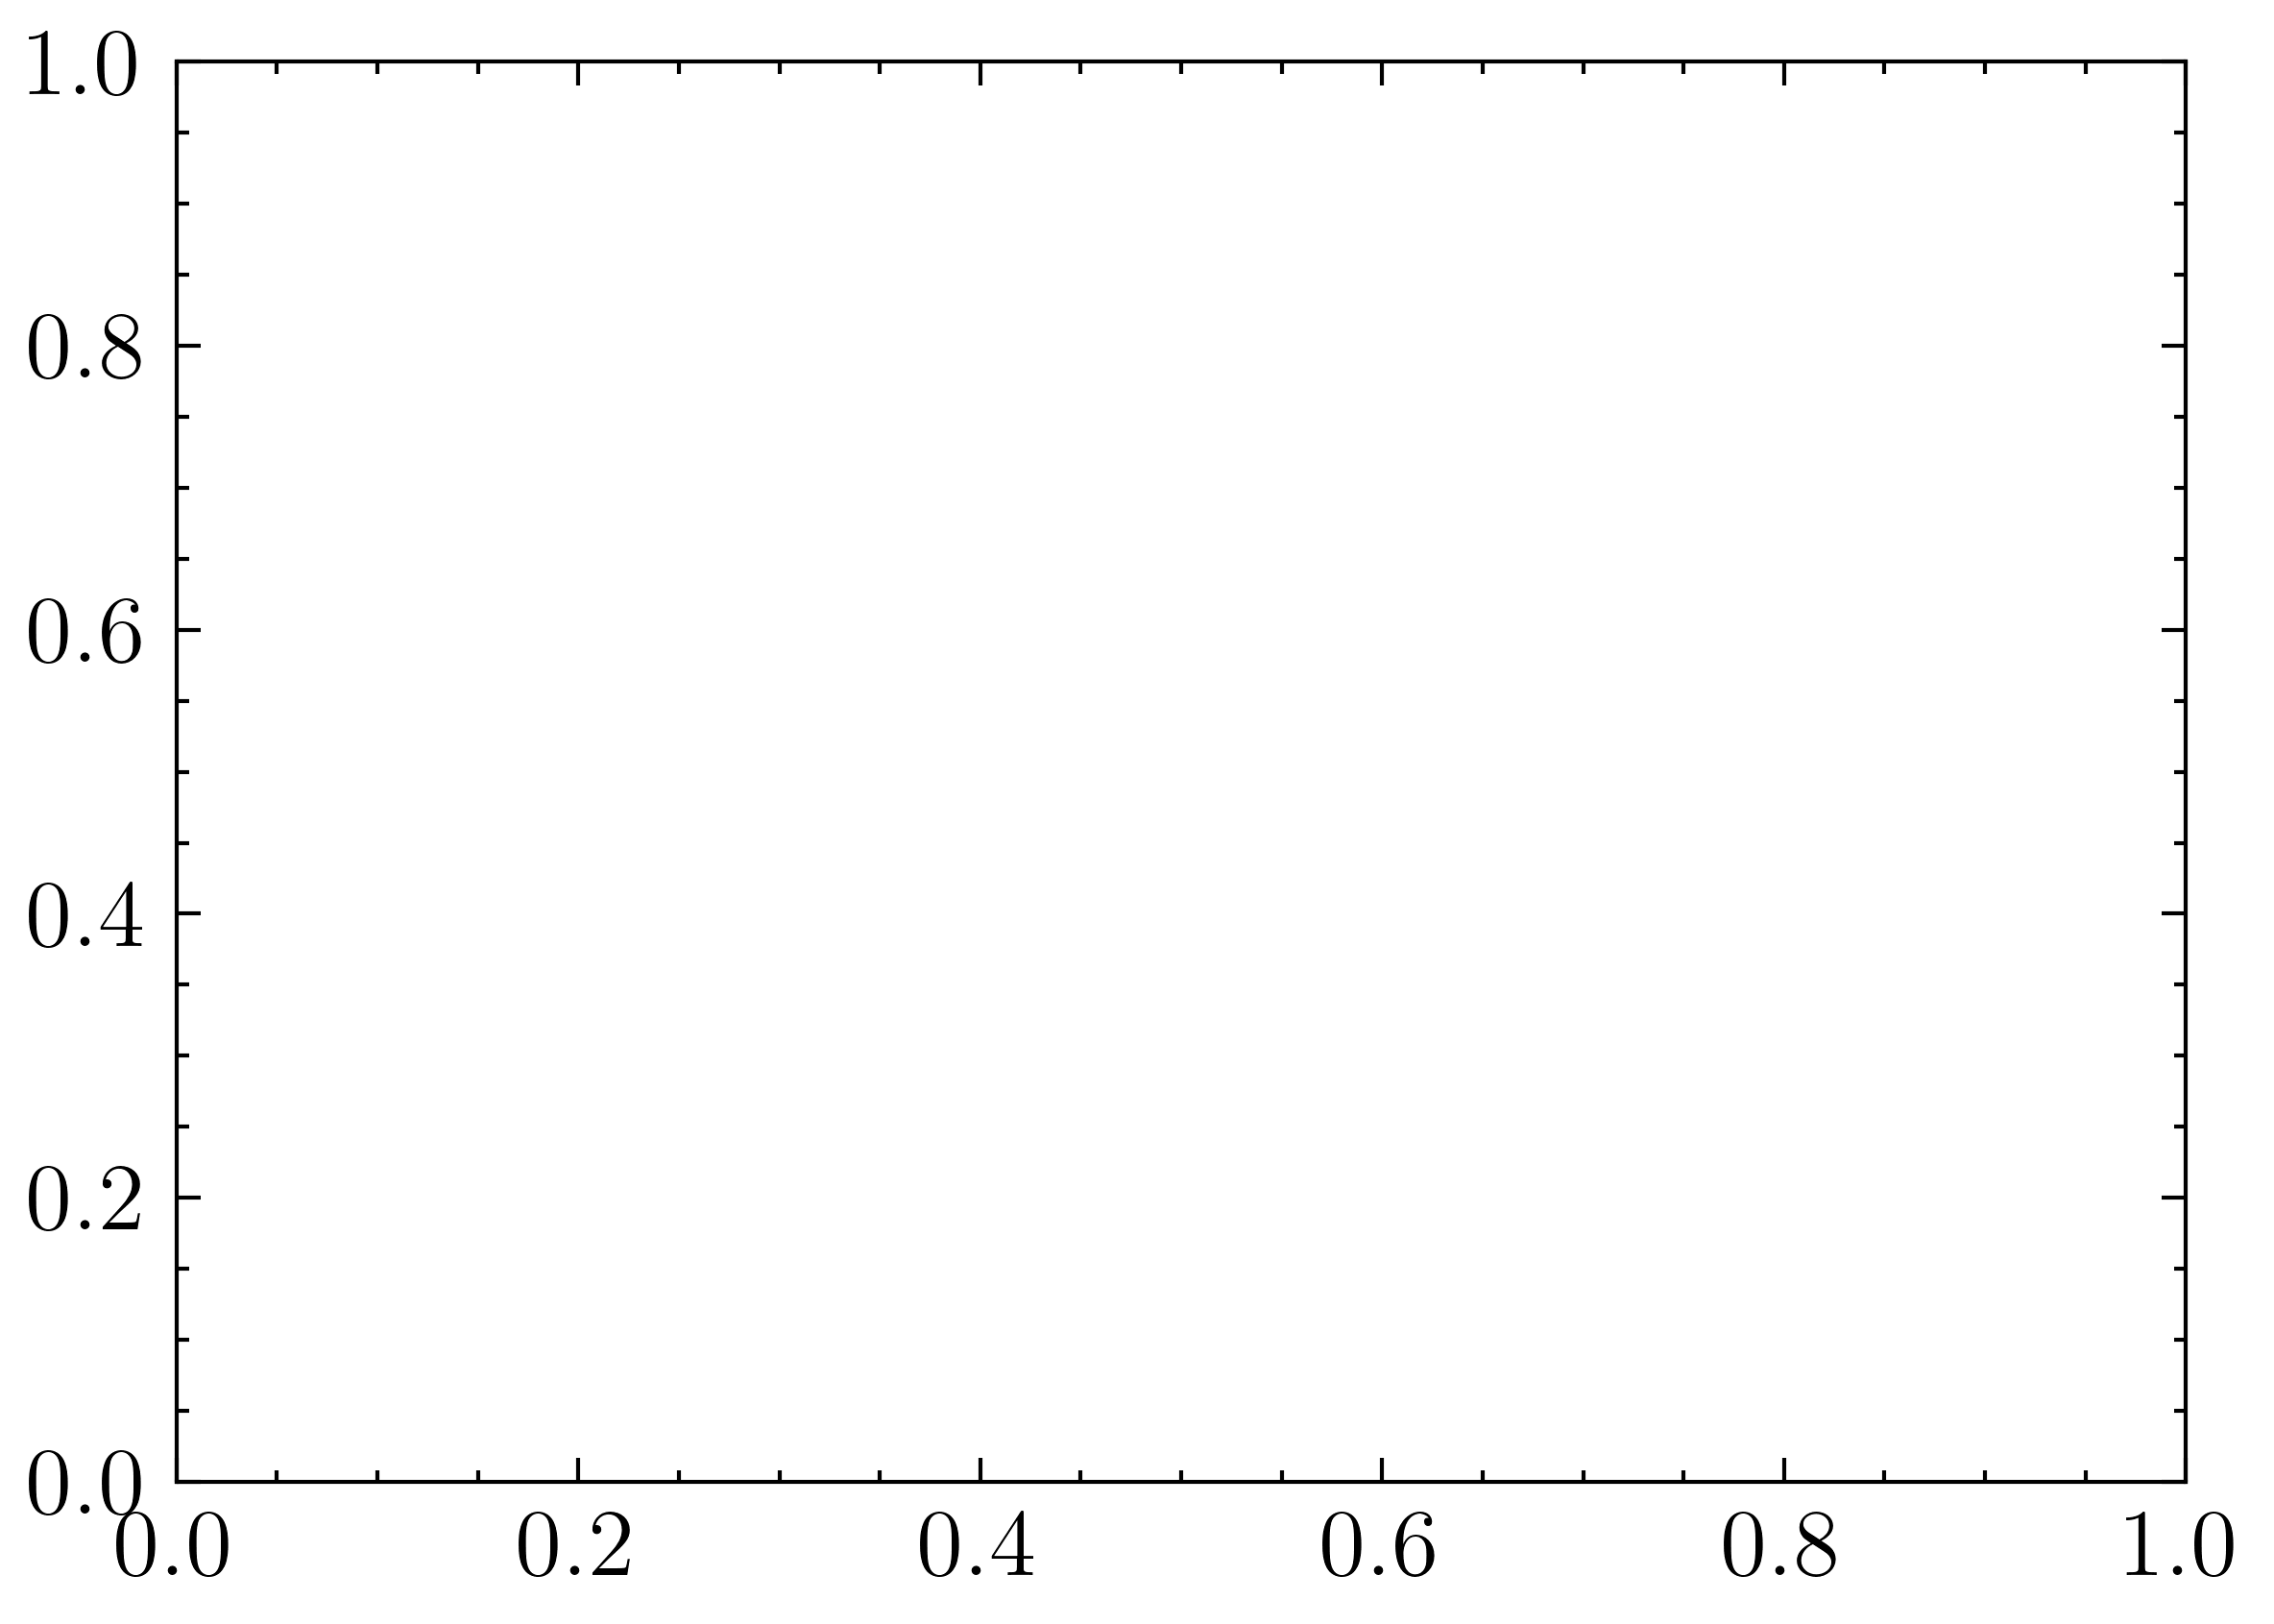

In [12]:

import numpy as np
import matplotlib.pyplot as plt

import scienceplots
plt.style.use(['science', "ieee"])
plt.rcParams['text.latex.preamble']=r'\usepackage{lmodern}'

plt.rcParams.update({
    'font.size': 20,  # Main font size
    'axes.labelsize': 15,  # Axis labels
    'axes.titlesize': 18,  # Title size
    'legend.fontsize': 12,  # Legend font
    'xtick.labelsize': 12,  # Tick labels
    'ytick.labelsize': 12,
    'font.family' : 'lmodern'
})

fig, ax = plt.subplots(1,figsize=(4.5, 3.2), sharey="row")
for acl in acls:
    counts, bin_edges = np.histogram(acl, bins=20)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # ax.hist(acl, bins=20, histtype="step", label="Histogram")
        
    # Add error bars
    ax.errorbar(bin_centers, counts, yerr=np.sqrt(counts), fmt='o', color='black', markersize=2, capsize=3)
    ax.plot(bin_centers, counts,color='black')

# plt.xlabel("Value")
# plt.ylabel("Counts")
# plt.legend()
# plt.show()


In [ ]:
dt_list = np.logspace(-1, -3, 3)
bins = 20

acls = []
acls_cupy = []
for dt in dt_list:
    this_acl = []
    sim = run_sim(dt, 1, auto_corr=dt/2, thermal_time = 0)

    for traj_idx in tqdm.tqdm(range(sim.trajs)):
        count = sim.trackers["2_moment"].history_counter_[:,traj_idx]
        mask = count > 0
        lt = sim.trackers["2_moment"].history_meas_times_[:,traj_idx][mask]/count[mask]
        dat = sim.trackers["2_moment"].history_result_[:,traj_idx][mask]/count[mask]
        # this_acl_cupy.append(dt*np.array(my_acf_cupy(dat, lmax = int(1/dt))))
        this_acl.append(dt*np.array(my_acl(dat, lmax = int(1/dt))))
    acls.append(this_acl)


100%|█████████▉| 0.9999999999999999/1 [00:00<00:00,  2.65it/s]
  0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_30265/3663734468.py:71: RuntimeWarning: overflow encountered in exp
  return np.exp(-x / tau)
100%|██████████| 1000/1000 [00:00<00:00, 1985.08it/s]
 98%|█████████▊| 0.9803060746521972/1 [00:00<00:00,  1.96it/s]
100%|██████████| 1000/1000 [00:00<00:00, 2202.16it/s]
 99%|█████████▉| 0.9900000000000007/1 [00:01<00:00,  1.65s/it]  
100%|██████████| 1000/1000 [00:00<00:00, 1983.83it/s]


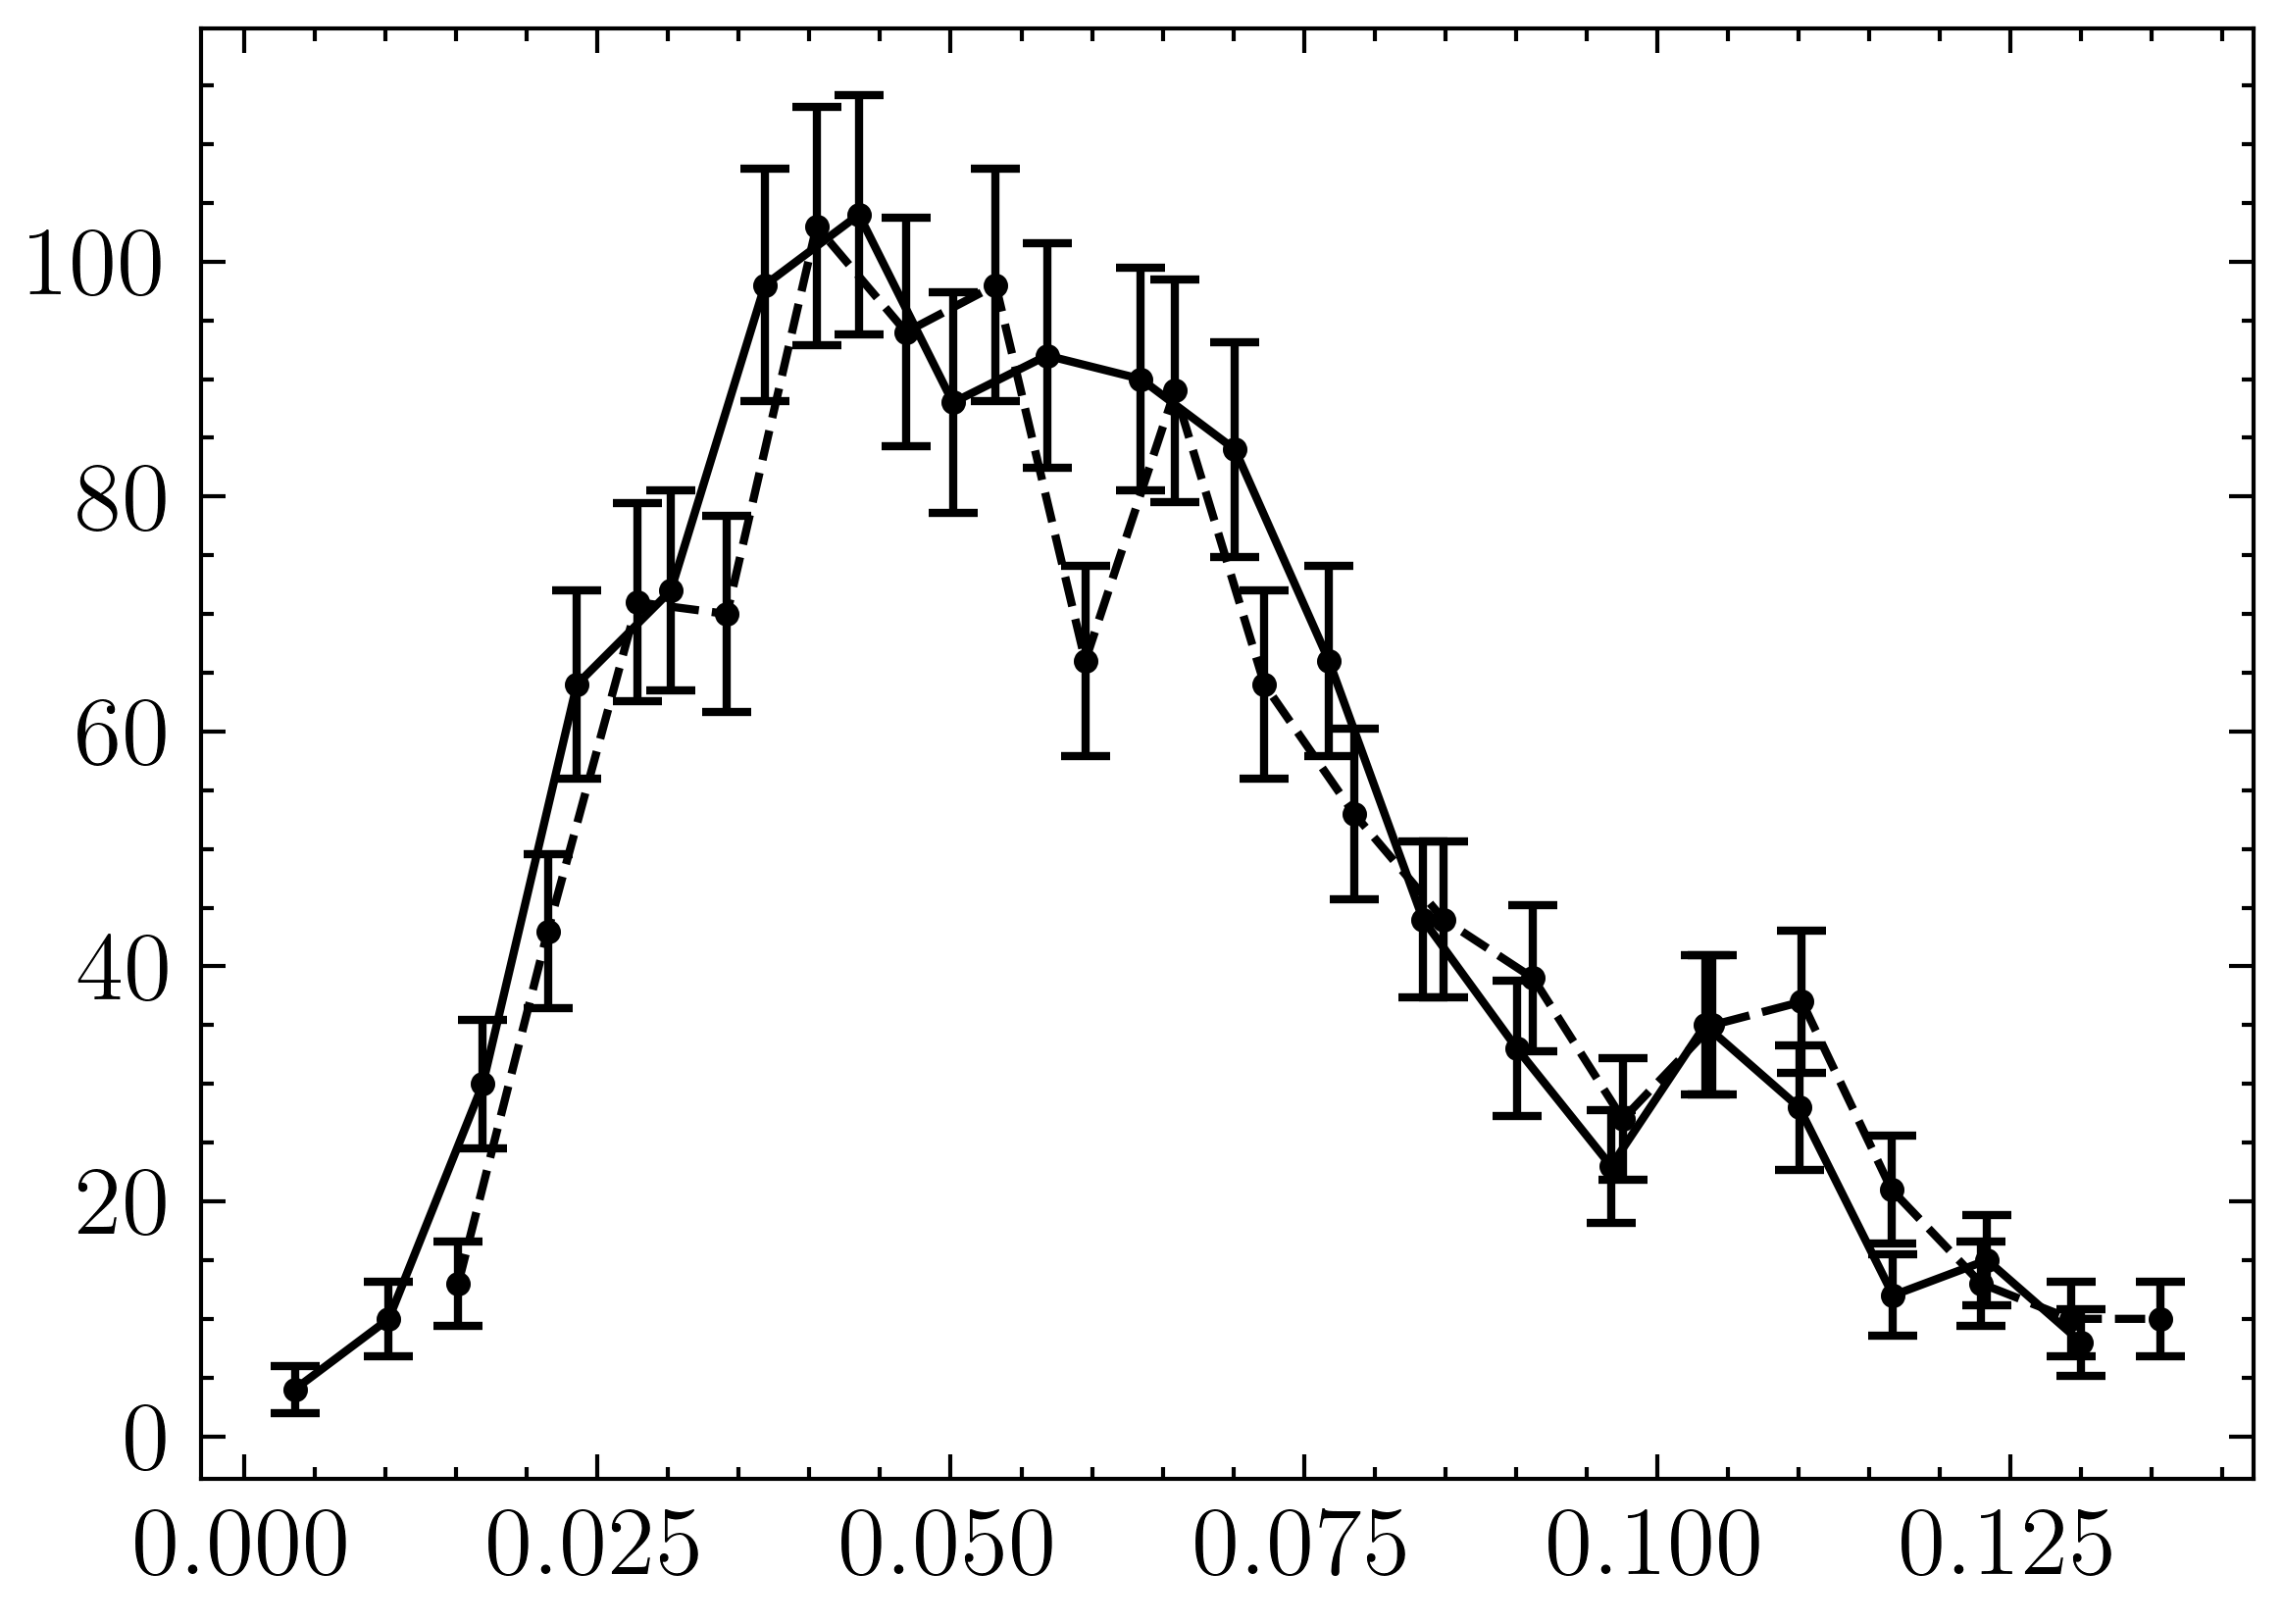

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

import scienceplots
plt.style.use(['science', "ieee"])
plt.rcParams['text.latex.preamble']=r'\usepackage{lmodern}'

plt.rcParams.update({
    'font.size': 20,  # Main font size
    'axes.labelsize': 15,  # Axis labels
    'axes.titlesize': 18,  # Title size
    'legend.fontsize': 12,  # Legend font
    'xtick.labelsize': 12,  # Tick labels
    'ytick.labelsize': 12,
    'font.family' : 'lmodern'
})

fig, ax = plt.subplots(1,figsize=(4.5, 3.2), sharey="row")
for acl in acls[1:]:
    counts, bin_edges = np.histogram(acl, bins=20)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # ax.hist(acl, bins=20, histtype="step", label="Histogram")
        
    # Add error bars
    ax.errorbar(bin_centers, counts, yerr=np.sqrt(counts), fmt='o', color='black', markersize=2, capsize=3)
    ax.plot(bin_centers, counts,color='black')

# plt.xlabel("Value")
# plt.ylabel("Counts")
# plt.legend()
# plt.show()

In [17]:


acls = []
sim = run_sim(1e-3, trajs=int(1e4), auto_corr=1e-3/10, thermal_time=0, maximal_lt=10, sigma=sigma, lamb=1, history_grid_size=1e-2, pullback=10, mass_modification=1)
sim.trackers["1_moment"].history_result

for traj in tqdm.tqdm(range(sim.trajs)):
    data1 = sim.trackers["1_moment"].history_result[traj]
    lt1 = sim.trackers["1_moment"].history_meas_times[traj]
    acl1 = my_acl(data1, lmax = int(2e3))
    acls.append(acl1)

sim = run_sim(5e-4, trajs=int(1e4), auto_corr=1e-3/10, thermal_time=0, maximal_lt=10, sigma=sigma, lamb=1, history_grid_size=1e-2, pullback=10, mass_modification=1)
data2 = sim.trackers["1_moment"].history_result
lt2 = sim.trackers["1_moment"].history_meas_times
acf2 = my_acf(data2)
acl2 = my_acl(data2, lmax = int(2e4))


sim = run_sim(1e-4, 10, auto_corr=1e-4/2, thermal_time = 0)
data3 = sim.trackers["1_moment"].history_result
lt3 = sim.trackers["1_moment"].history_meas_times

 51%|█████     | 5.054657742560041/10 [00:33<00:32,  6.61s/it]   


KeyboardInterrupt: 

In [12]:
sim.trackers["1_moment"].history_result[traj]

(0.026304467037822105+0j)

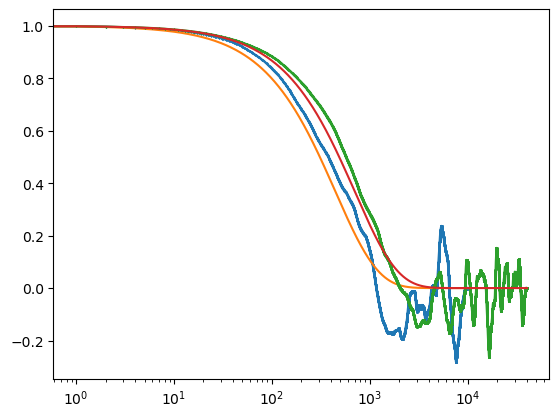

In [34]:
lag = np.array(range(acf1.size))
plt.semilogx(lag, acf1, marker="x", markersize=1)
plt.semilogx(lag, fit_exp(lag, acl1))

lag = np.array(range(acf2.size))
plt.semilogx(lag, acf2, marker="x", markersize=1)
plt.semilogx(lag, fit_exp(lag, acl2))

  0%|          | 0/20 [00:00<?, ?it/s]

100%|█████████▉| 19.99999999999874/20 [00:05<00:00,  3.88it/s]  
/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/numpy/lib/function_base.py:486: ComplexWarning: Casting complex values to real discards the imaginary part
  a = asarray(a, dtype=dtype, order=order)
100%|█████████▉| 39.99975000009998/40 [00:20<00:00,  1.93it/s]  
/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/fabianhelmberger/miniconda3/envs/cle_cuda/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


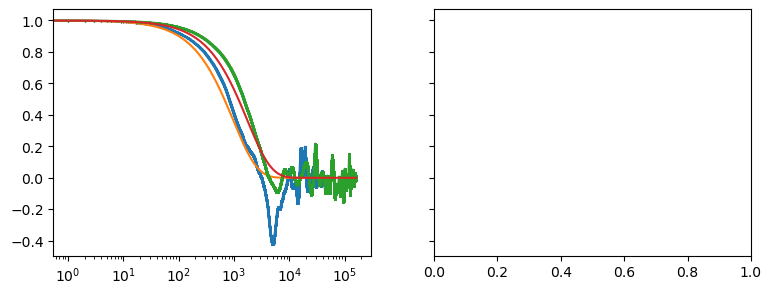

In [ ]:


base_dt = 1e-3
base_lmax = 1e3
base_auto_corr = 1e-3
base_lt = 10

data = []
dt = []
lmax = []
acf = []
acl = []

for factor in range(1, 3):
    dt_val = base_dt/2**factor
  
    sim = run_sim(dt_val, base_lt*2**factor, auto_corr=dt_val/2, thermal_time = 0)
    data = sim.trackers["1_moment"].history_result
    lt = sim.trackers["1_moment"].history_meas_times
    acf.append(my_acf(data))
    acl.append(my_acl(data, lmax = int(10/dt_val)))


# sim = run_sim(1e-4, 10, auto_corr=1e-4/2, thermal_time = 0)
# data3 = sim.trackers["1_moment"].history_result
# lt3 = sim.trackers["1_moment"].history_meas_times
fig, ax = plt.subplots(1,2,figsize=(9, 3.2), sharey="row")
ax = ax.flatten()

for acf_val, acl_val in zip(acf, acl):
        
    lag = np.array(range(acf_val.size))
    ax[0].semilogx(lag, acf_val, marker="x", markersize=1)
    ax[0].semilogx(lag, fit_exp(lag, acl_val))